In [1]:
import cv2
import numpy as np
import random
from collections import deque, namedtuple

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


Map: (384, 384) Fixed Start: (138, 182) Example Goal: (172, 244)


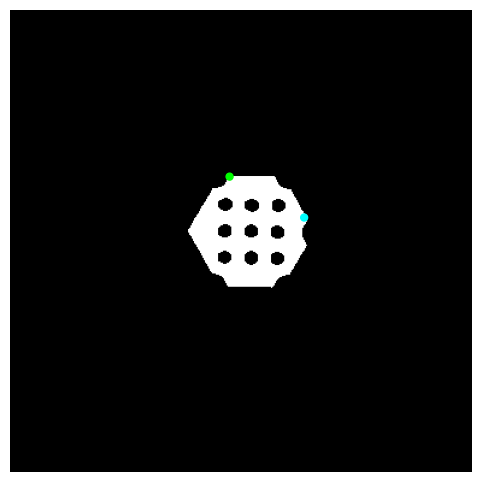

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG_PATH = "/content/map2v2.png"

img = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(IMG_PATH)

H, W = img.shape
THRESH = 200
occ = (img < THRESH).astype(np.uint8)  # 1=obstacle, 0=free

# Fixed start: first free cell from top-left (same as before)
start = None
for r in range(H):
    for c in range(W):
        if occ[r, c] == 0:
            start = (r, c)
            break
    if start is not None:
        break
if start is None:
    raise ValueError("No free start found.")

# All free cells for sampling random goals
free_rc = np.column_stack(np.where(occ == 0))  # (N,2), each row [r,c]

def sample_goal_fixed_start(start_rc, min_manhattan=30, max_tries=5000):
    sr, sc = start_rc
    for _ in range(max_tries):
        idx = np.random.randint(len(free_rc))
        gr, gc = int(free_rc[idx, 0]), int(free_rc[idx, 1])
        if (gr, gc) == (sr, sc):
            continue
        if abs(gr - sr) + abs(gc - sc) < min_manhattan:
            continue
        return (gr, gc)
    # fallback
    while True:
        idx = np.random.randint(len(free_rc))
        gr, gc = int(free_rc[idx, 0]), int(free_rc[idx, 1])
        if (gr, gc) != start_rc:
            return (gr, gc)

goal_example = sample_goal_fixed_start(start, min_manhattan=30)
print("Map:", (H, W), "Fixed Start:", start, "Example Goal:", goal_example)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.scatter([start[1], goal_example[1]], [start[0], goal_example[0]], c=["lime", "cyan"], s=25)
plt.axis("off")
plt.show()

In [3]:
class XYEnv:
    # actions: 0=up,1=down,2=left,3=right
    def __init__(self, occ, start, goal, max_steps=1500):
        self.occ = occ
        self.H, self.W = occ.shape
        self.start = start
        self.goal = goal
        self.max_steps = max_steps
        self.reset()

    def reset(self, goal=None):
        if goal is not None:
            self.goal = goal
        self.pos = self.start
        self.steps = 0
        return self._state()

    def _state(self):

        r,c = self.pos
        gr,gc = self.goal

        x = c/(self.W-1)
        y = r/(self.H-1)

        gx = gc/(self.W-1)
        gy = gr/(self.H-1)

        dx = gx - x
        dy = gy - y

        # 8-direction obstacle sensing
        dirs = [(-1,0),(1,0),(0,-1),(0,1),
                (-1,-1),(-1,1),(1,-1),(1,1)]

        obs = []
        for dr,dc in dirs:
            nr = r+dr
            nc = c+dc
            if 0<=nr<self.H and 0<=nc<self.W:
                obs.append(self.occ[nr,nc])
            else:
                obs.append(1)

        return np.array([x,y,dx,dy] + obs, dtype=np.float32)

    def step(self, action):

        r, c = self.pos
        gr, gc = self.goal

        prev_dist = abs(r - gr) + abs(c - gc)

        # movement
        if action == 0:
            nr, nc = r - 1, c
        elif action == 1:
            nr, nc = r + 1, c
        elif action == 2:
            nr, nc = r, c - 1
        else:
            nr, nc = r, c + 1

        collision = False

        # boundary or obstacle
        if not (0 <= nr < self.H and 0 <= nc < self.W) or self.occ[nr, nc] == 1:
            nr, nc = r, c
            collision = True

        self.pos = (nr, nc)
        self.steps += 1

        # distance after move
        new_dist = abs(nr - gr) + abs(nc - gc)

        # ⭐ Distance shaping reward
        reward = (prev_dist - new_dist) * 2.0

        # small step penalty
        reward -= 0.05

        # collision penalty
        if collision:
            reward -= 5

        done = False

        # GOAL REACHED
        if self.pos == self.goal:
            reward += 200
            done = True

        # timeout
        if self.steps >= self.max_steps:
            done = True

        return self._state(), reward, done, {}

In [4]:
import random
from collections import deque, namedtuple
import torch
import torch.nn as nn

class QNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

          nn.Linear(12,256),
          nn.ReLU(),

          nn.Linear(256,256),
          nn.ReLU(),

          nn.Linear(256,128),
          nn.ReLU(),

          nn.Linear(128,4)

      )

    def forward(self, x):
        return self.net(x)

Transition = namedtuple("Transition", ("s","a","r","ns","done"))

class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, ns, done):
        self.buf.append(Transition(s, a, r, ns, done))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buf)

In [5]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def train_dqn_fast(
    env,
    episodes=1200,
    gamma=0.99,
    lr=1e-4,
    batch_size=128,
    replay_capacity=100000,
    warmup=1500,
    target_update=2000,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=150000,
):
    qnet = QNet().to(device)
    tgt  = QNet().to(device)
    tgt.load_state_dict(qnet.state_dict())
    tgt.eval()

    opt = optim.Adam(qnet.parameters(), lr=lr)
    replay = ReplayBuffer(capacity=replay_capacity)

    global_step = 0

    def eps_by_step(step):
        frac = min(1.0, step / float(eps_decay_steps))
        return eps_start + frac * (eps_end - eps_start)

    for ep in range(1, episodes + 1):
        g = sample_goal_fixed_start(env.start, min_manhattan=30)

        # ⭐ NEW ADDITION
        while not is_reachable(env.start, g):
            g = sample_goal_fixed_start(env.start, min_manhattan=30)

        s = env.reset(goal=g)

        ep_ret = 0.0
        done = False

        while not done:
            eps = eps_by_step(global_step)

            if random.random() < eps:
                a = random.randrange(4)
            else:
                with torch.no_grad():
                    st = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
                    a = int(torch.argmax(qnet(st), dim=1).item())

            ns, r, done, _ = env.step(a)
            replay.push(s, a, r, ns, done)

            s = ns
            ep_ret += r
            global_step += 1

            if len(replay) >= warmup:
                batch = replay.sample(batch_size)

                sb  = torch.tensor(np.array(batch.s),  dtype=torch.float32, device=device)
                ab  = torch.tensor(batch.a, dtype=torch.long, device=device)
                rb  = torch.tensor(batch.r, dtype=torch.float32, device=device)
                nsb = torch.tensor(np.array(batch.ns), dtype=torch.float32, device=device)
                db  = torch.tensor(batch.done, dtype=torch.float32, device=device)

                q = qnet(sb).gather(1, ab.unsqueeze(1)).squeeze(1)

                with torch.no_grad():

                  # ⭐ Double DQN
                  next_actions = qnet(nsb).argmax(dim=1)

                  q_next = tgt(nsb).gather(
                      1,
                      next_actions.unsqueeze(1)
                  ).squeeze(1)

                  y = rb + gamma * (1.0 - db) * q_next

                # Huber loss is more stable than MSE
                loss = torch.nn.functional.smooth_l1_loss(q, y)

                opt.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(qnet.parameters(), 5.0)
                opt.step()

                if global_step % target_update == 0:
                    tgt.load_state_dict(qnet.state_dict())

        if ep % 100 == 0:
            print(f"Ep {ep:4d} | return {ep_ret:7.2f} | eps {eps_by_step(global_step):.3f} | goal {env.goal} | buf {len(replay)}")

    return qnet

Device: cuda


Ep  100 | return  158.75 | eps 0.762 | md 10 | goal (216, 176) | buf 75237
Ep  200 | return  272.05 | eps 0.663 | md 10 | goal (217, 177) | buf 106286
Ep  300 | return  389.95 | eps 0.593 | md 10 | goal (192, 232) | buf 128471
Ep  400 | return  255.05 | eps 0.527 | md 10 | goal (170, 176) | buf 149336
Ep  500 | return  388.95 | eps 0.471 | md 25 | goal (198, 227) | buf 166913
Ep  600 | return  327.10 | eps 0.420 | md 25 | goal (177, 209) | buf 183128
Ep  700 | return  313.55 | eps 0.371 | md 25 | goal (186, 168) | buf 198534
Ep  800 | return  418.20 | eps 0.330 | md 25 | goal (196, 242) | buf 200000
Ep  900 | return  381.80 | eps 0.290 | md 25 | goal (210, 236) | buf 200000
Ep 1000 | return  303.15 | eps 0.251 | md 25 | goal (169, 207) | buf 200000
Ep 1100 | return  432.50 | eps 0.217 | md 25 | goal (201, 242) | buf 200000
Ep 1200 | return  370.30 | eps 0.185 | md 45 | goal (225, 183) | buf 200000
Ep 1300 | return  292.35 | eps 0.142 | md 45 | goal (160, 210) | buf 200000
Ep 1400 | ret

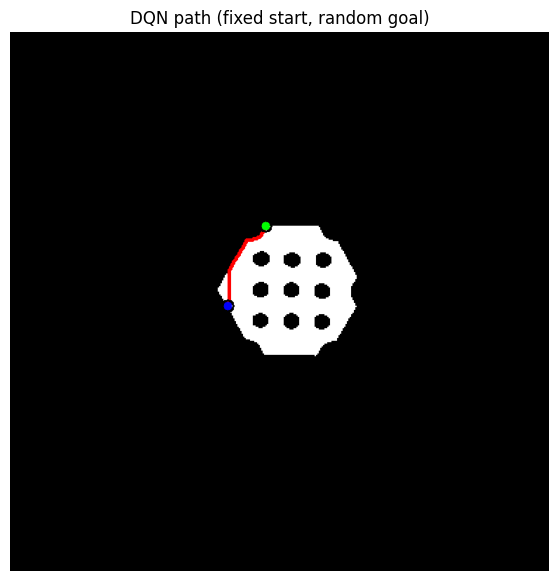

In [6]:


import numpy as np
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
import cv2
import matplotlib.pyplot as plt

# ----------------------------
# 0) Free-cell list + goal sampler
# ----------------------------
free_rc = np.column_stack(np.where(occ == 0))  # (N,2) row,col

def sample_goal_from_fixed_start(start_rc, min_manhattan=10, max_tries=20000):
    sr, sc = start_rc
    for _ in range(max_tries):
        gr, gc = map(int, free_rc[np.random.randint(len(free_rc))])
        if (gr, gc) == (sr, sc):
            continue
        if abs(gr - sr) + abs(gc - sc) < min_manhattan:
            continue
        return (gr, gc)
    # fallback
    while True:
        gr, gc = map(int, free_rc[np.random.randint(len(free_rc))])
        if (gr, gc) != start_rc:
            return (gr, gc)

# ----------------------------
# 1) Greedy rollout for visualization after training
# ----------------------------
def rollout_path_4in(env, qnet, max_steps=2000):
    # assumes env already has desired start/goal set
    s = env.reset(goal=env.goal)
    qnet.eval()
    path = [env.pos]

    for _ in range(max_steps):
        with torch.no_grad():
            st = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
            a = int(torch.argmax(qnet(st), dim=1).item())

        s, r, done, _ = env.step(a)
        path.append(env.pos)
        if done:
            break
    return path

# ----------------------------
# 2) DQN trainer (Fixed start, Random goal)
# ----------------------------
def train_fixed_start_random_goal(
    env,
    episodes=3000,
    gamma=0.99,
    lr=5e-4,
    batch_size=128,
    replay_capacity=200000,
    warmup=10000,
    train_freq=4,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=300000,
    target_update=2000,
):
    qnet = QNet().to(device)
    tgt  = QNet().to(device)
    tgt.load_state_dict(qnet.state_dict())
    tgt.eval()

    opt = optim.Adam(qnet.parameters(), lr=lr)
    replay = ReplayBuffer(capacity=replay_capacity)
    global_step = 0

    def eps_by_step(step):
        frac = min(1.0, step / float(eps_decay_steps))
        return eps_start + frac * (eps_end - eps_start)

    # curriculum on goal distance (helps learning a lot)
    def min_dist(ep):
        if ep < 500:   return 10
        if ep < 1200:  return 25
        if ep < 2200:  return 45
        return 70

    fixed_start = env.start

    for ep in range(1, episodes + 1):
        md = min_dist(ep)
        g = sample_goal_from_fixed_start(fixed_start, min_manhattan=md)

        # IMPORTANT: start stays fixed, goal changes
        s = env.reset(goal=g)
        ep_ret = 0.0
        done = False

        while not done:
            eps = eps_by_step(global_step)

            # epsilon-greedy
            if random.random() < eps:
                a = random.randrange(4)
            else:
                with torch.no_grad():
                    st = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
                    a = int(torch.argmax(qnet(st), dim=1).item())

            ns, r, done, _ = env.step(a)
            replay.push(s, a, r, ns, done)

            s = ns
            ep_ret += float(r)
            global_step += 1

            # learn
            if len(replay) >= warmup and (global_step % train_freq == 0):
                batch = replay.sample(batch_size)

                sb  = torch.tensor(np.array(batch.s),  dtype=torch.float32, device=device)
                ab  = torch.tensor(batch.a, dtype=torch.long, device=device)
                rb  = torch.tensor(batch.r, dtype=torch.float32, device=device)
                nsb = torch.tensor(np.array(batch.ns), dtype=torch.float32, device=device)
                db  = torch.tensor(batch.done, dtype=torch.float32, device=device)

                q = qnet(sb).gather(1, ab.unsqueeze(1)).squeeze(1)

                # Double DQN target
                with torch.no_grad():
                    a_next = torch.argmax(qnet(nsb), dim=1)  # action from online
                    q_next = tgt(nsb).gather(1, a_next.unsqueeze(1)).squeeze(1)  # value from target
                    y = rb + gamma * (1.0 - db) * q_next

                # Huber loss (more stable than MSE)
                loss = F.smooth_l1_loss(q, y)

                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(qnet.parameters(), 5.0)
                opt.step()

                tau = 0.005
                for tp, p in zip(tgt.parameters(), qnet.parameters()):
                    tp.data.copy_(tau*p.data + (1-tau)*tp.data)

        if ep % 100 == 0:
            print(f"Ep {ep:4d} | return {ep_ret:7.2f} | eps {eps_by_step(global_step):.3f} "
                  f"| md {md} | goal {env.goal} | buf {len(replay)}")

    return qnet

# ----------------------------
# 3) RUN TRAINING + SAVE (this is your "cell6", corrected)
# ----------------------------

env = XYEnv(occ, start=start, goal=goal_example, max_steps=2000)

qnet = train_fixed_start_random_goal(env, episodes=3000)

MODEL_4_PATH = "/content/qnet_fixed_start.pth"
torch.save(qnet.state_dict(), MODEL_4_PATH)
print("Saved:", MODEL_4_PATH)

# Verify checkpoint really has 12 inputs
sd = torch.load(MODEL_4_PATH, map_location="cpu")
print("Checkpoint net.0.weight shape:", sd["net.0.weight"].shape)
# Should now be torch.Size([256, 12])

# ----------------------------
# 4) VISUALIZE ONE EPISODE AFTER TRAINING (optional)
# ----------------------------
# Use the last training goal (env.goal) or set an example goal:
# env.goal = sample_goal_from_fixed_start(env.start, min_manhattan=50)

path = rollout_path_4in(env, qnet, max_steps=2000)

scale = 2
path_thickness = 4
start_radius   = 6
goal_radius    = 6

overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
if scale != 1:
    overlay = cv2.resize(
        overlay,
        (overlay.shape[1]*scale, overlay.shape[0]*scale),
        interpolation=cv2.INTER_NEAREST
    )

if len(path) >= 2:
    pts = np.array([(c*scale, r*scale) for (r,c) in path], dtype=np.int32).reshape((-1,1,2))
    cv2.polylines(overlay, [pts], isClosed=False, color=(0,0,255), thickness=path_thickness)

sx, sy = env.start[1]*scale, env.start[0]*scale
gx, gy = env.goal[1]*scale,  env.goal[0]*scale

cv2.circle(overlay, (sx, sy), start_radius, (0,255,0), -1)
cv2.circle(overlay, (sx, sy), start_radius+2, (0,0,0), 2)

cv2.circle(overlay, (gx, gy), goal_radius, (255,0,0), -1)
cv2.circle(overlay, (gx, gy), goal_radius+2, (0,0,0), 2)

plt.figure(figsize=(7,7))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("DQN path (fixed start, random goal)")
plt.axis("off")
plt.show()

In [7]:
import cv2
import numpy as np
img_path = "/content/map2v2.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
  raise FileNotFoundError(f"Could not load image: {img_path}")
H, W = img.shape
print("Image size (H, W):", H, W)
assert (H, W) == (384, 384), f"Expected (384,384) but got {(H,W)}"

# 3) Threshold to get binary map (white=255 free, black=0 obstacle)
_, bw = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY
                      + cv2.THRESH_OTSU)

# 4) Free pixel coordinates in (row, col)
free_rc = np.column_stack(np.where(bw == 255)) # shape (N,2)

print("Total free pixels:", free_rc.shape[0])
print("First 10 free pixels (row, col):\n", free_rc[:10])

# 5) If you want (x,y) instead of (row,col)
free_xy = free_rc[:, [1, 0]] # (x, y) = (col, row)
print("First 10 free pixels (x, y):\n", free_xy[:10])

# 6) Optional: save
np.save("free_pixels_rc_384.npy", free_rc)
np.savetxt("free_pixels_rc_384.csv", free_rc, fmt="%d", delimiter=",",
           header="row,col", comments="")



Image size (H, W): 384 384
Total free pixels: 5952
First 10 free pixels (row, col):
 [[138 182]
 [138 183]
 [138 184]
 [138 185]
 [138 186]
 [138 187]
 [138 188]
 [138 189]
 [138 190]
 [138 191]]
First 10 free pixels (x, y):
 [[182 138]
 [183 138]
 [184 138]
 [185 138]
 [186 138]
 [187 138]
 [188 138]
 [189 138]
 [190 138]
 [191 138]]


Loaded model from: /content/qnet_fixed_start.pth
First layer: Linear(in_features=12, out_features=256, bias=True)
Fixed Start rc: (138, 182) occ: 0
Goal rc (snapped): (184, 148) occ: 0
BFS reachability from start to goal: True
Start rc: (138, 182) Goal rc: (184, 148)
Initial state [x,y,dx,dy]: [ 0.47519583  0.36031333 -0.08877285  0.12010444  1.          0.
  1.          0.          1.          1.          0.          0.        ]

==== TEST RESULT ====
Reached   : True
Steps     : 109
Collisions: 1
Return    : 349.54999999999995


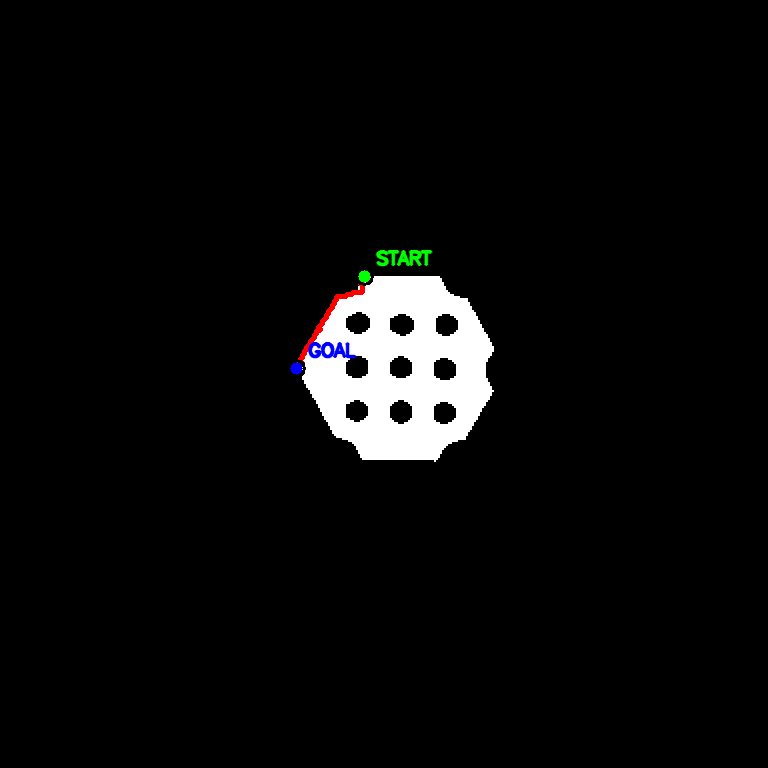

In [38]:
import numpy as np
import cv2
import torch

# ============================================================
# COMPLETE TESTING CODE
# Works for FIXED-START training (start must be the same as training)
# Adds: BFS reachability check + correct rollout bookkeeping
# ============================================================

# ---------------------------
# 0) Helpers
# ---------------------------
def snap_to_free(occ, rc, max_radius=40):
    H, W = occ.shape
    r0, c0 = rc
    if not (0 <= r0 < H and 0 <= c0 < W):
        raise ValueError(f"Point {rc} out of bounds (H,W)=({H},{W})")
    if occ[r0, c0] == 0:
        return rc

    best = None
    best_d2 = 10**18
    for rad in range(1, max_radius + 1):
        rmin = max(0, r0 - rad); rmax = min(H - 1, r0 + rad)
        cmin = max(0, c0 - rad); cmax = min(W - 1, c0 + rad)
        for r in range(rmin, rmax + 1):
            for c in range(cmin, cmax + 1):
                if occ[r, c] == 0:
                    d2 = (r - r0) * (r - r0) + (c - c0) * (c - c0)
                    if d2 < best_d2:
                        best_d2 = d2
                        best = (r, c)
        if best is not None:
            return best
    raise ValueError(f"No free cell found near {rc} within radius {max_radius}")


def draw_path_on_map(gray_img, path, start, goal, scale=2,
                     path_thickness=4, start_radius=6, goal_radius=6):
    overlay = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)

    if scale != 1:
        overlay = cv2.resize(
            overlay,
            (overlay.shape[1] * scale, overlay.shape[0] * scale),
            interpolation=cv2.INTER_NEAREST
        )

    if len(path) >= 2:
        pts = np.array([(c * scale, r * scale) for (r, c) in path],
                       dtype=np.int32).reshape((-1, 1, 2))
        cv2.polylines(overlay, [pts], isClosed=False, color=(0, 0, 255),
                      thickness=path_thickness)

    sx, sy = start[1] * scale, start[0] * scale
    gx, gy = goal[1] * scale,  goal[0] * scale

    cv2.circle(overlay, (sx, sy), start_radius, (0, 255, 0), -1)
    cv2.circle(overlay, (sx, sy), start_radius + 2, (0, 0, 0), 2)

    cv2.circle(overlay, (gx, gy), goal_radius, (255, 0, 0), -1)
    cv2.circle(overlay, (gx, gy), goal_radius + 2, (0, 0, 0), 2)

    cv2.putText(overlay, "START", (sx + 12, sy - 12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)
    cv2.putText(overlay, "GOAL",  (gx + 12, gy - 12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2, cv2.LINE_AA)

    return overlay


# ---------------------------
# 0.1) BFS reachability check (very important!)
# ---------------------------
from collections import deque

def reachable_bfs(occ, start_rc, goal_rc, max_nodes=300000):
    """
    Returns True if goal reachable from start through free cells (occ==0).
    max_nodes prevents runaway on huge open spaces; increase if needed.
    """
    H, W = occ.shape
    sr, sc = start_rc
    gr, gc = goal_rc
    if occ[sr, sc] != 0 or occ[gr, gc] != 0:
        return False

    q = deque([start_rc])
    visited = np.zeros((H, W), dtype=np.uint8)
    visited[sr, sc] = 1
    seen = 0

    while q:
        r, c = q.popleft()
        if (r, c) == (gr, gc):
            return True

        seen += 1
        if seen > max_nodes:
            # treat as reachable unknown; you can raise max_nodes if needed
            return True

        # 4-neighbors
        if r > 0 and not visited[r-1, c] and occ[r-1, c] == 0:
            visited[r-1, c] = 1; q.append((r-1, c))
        if r+1 < H and not visited[r+1, c] and occ[r+1, c] == 0:
            visited[r+1, c] = 1; q.append((r+1, c))
        if c > 0 and not visited[r, c-1] and occ[r, c-1] == 0:
            visited[r, c-1] = 1; q.append((r, c-1))
        if c+1 < W and not visited[r, c+1] and occ[r, c+1] == 0:
            visited[r, c+1] = 1; q.append((r, c+1))

    return False


# ---------------------------
# Load Model
# ---------------------------
MODEL_4_PATH = "/content/qnet_fixed_start.pth"   # use the model trained with fixed-start + random-goal
# If yours is qnet_4in.pth, set that here.

qnet_test = QNet().to(device)
qnet_test.load_state_dict(torch.load(MODEL_4_PATH, map_location=device))
qnet_test.eval()

print("Loaded model from:", MODEL_4_PATH)
print("First layer:", qnet_test.net[0])  # must be Linear(12,256)

# ---------------------------
# 2) Greedy rollout (12-input env)
# ---------------------------
def greedy_rollout_4in(env, qnet, start_rc, goal_rc, max_steps=2000, verbose=True):
    # Make sure env is set correctly
    env.start = start_rc
    _ = env.reset(goal=goal_rc)   # ensures env.goal is set + resets pos to env.start (if your reset does that)
    env.pos = start_rc
    env.steps = 0

    s = env._state()  # [x,y,dx,dy]

    if verbose:
        print("Start rc:", env.start, "Goal rc:", env.goal)
        print("Initial state [x,y,dx,dy]:", s)

    path = [env.pos]
    total_reward = 0.0
    collisions = 0

    for _ in range(max_steps):
        with torch.no_grad():
            st = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
            if random.random() < 0.05:
                a = random.randint(0,3)
            else:
                a = int(torch.argmax(qnet(st), dim=1).item())

        prev_pos = env.pos
        ns, r, done, _ = env.step(a)

        if env.pos == prev_pos:
            collisions += 1

        total_reward += float(r)
        path.append(env.pos)

        s = ns  # ns is already env._state() in your env

        if done:
            break

    return {
        "reached": (env.pos == env.goal),
        "steps": len(path) - 1,
        "collisions": collisions,
        "return": total_reward,
        "path": path
    }

# ---------------------------
# 3) Choose goal (manual), FIXED start (same as training)
# ---------------------------
# IMPORTANT: For fixed-start training, do NOT change start during testing.
# Use the same 'start' you computed from the map in your earlier cell.
start_rc = start   # fixed start from training

# manual goal (x,y) -> (row,col)
my_goal_xy = (138,189)            # EDIT THIS
goal_rc = (my_goal_xy[1], my_goal_xy[0])
goal_rc = snap_to_free(occ, goal_rc, max_radius=40)

print("Fixed Start rc:", start_rc, "occ:", occ[start_rc])
print("Goal rc (snapped):", goal_rc, "occ:", occ[goal_rc])

# ---------------------------
# 3.1) Check reachability (if False, no policy can reach it)
# ---------------------------
ok = reachable_bfs(occ, start_rc, goal_rc)
print("BFS reachability from start to goal:", ok)
if not ok:
    print("WARNING: Goal is NOT reachable from the fixed start (disconnected free space). Pick another goal.")

# ---------------------------
# 4) Run test
# ---------------------------
env_test = XYEnv(occ, start=start_rc, goal=goal_rc, max_steps=2000)
out = greedy_rollout_4in(env_test, qnet_test, start_rc, goal_rc, max_steps=2000, verbose=True)

print("\n==== TEST RESULT ====")
print("Reached   :", out["reached"])
print("Steps     :", out["steps"])
print("Collisions:", out["collisions"])
print("Return    :", out["return"])

# ---------------------------
# 5) Visualize
# ---------------------------
overlay = draw_path_on_map(
    img, out["path"], start_rc, goal_rc,
    scale=2, path_thickness=4, start_radius=6, goal_radius=6
)

from google.colab.patches import cv2_imshow
cv2_imshow(overlay)